# Basic usage

In [1]:
import numpy as np
from matplotlib import pyplot as plt

import taichi as ti
ti.init(
    arch=ti.cpu,
    default_fp=ti.f64,
    cpu_max_num_threads=1,
    offline_cache=False,
    debug=True,
)

import lal
import bilby

from pespace.detector.antenna import InterferometerAntenna, FDResponseModelMarset2018
from pespace.detector.tdi import TDIChannelData, FDMichelsonConstantEqualArm
from pespace.detector.orbit import available_orbit_models, ConstellationVectorStruct
from tiwave.waveforms import IMRPhenomXAS, IMRPhenomXHM


[Taichi] version 1.7.4, llvm 15.0.4, commit b4b956fd, linux, python 3.10.19
[Taichi] Starting on arch=x64


[I 02/05/26 15:56:22.404 196615] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout
/tmp/ipykernel_196615/845489508.py:13: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
tdi_gen = "2.0"
tdi_chan = ("A", "E", "T")

dt = 5.0
f_min = 1e-5
f_max = 0.5*(1/dt)
f_ref = f_min
t_start = 0.0

num_tsamples = 2**np.ceil(np.log2(7*lal.DAYJUL_SI/dt))
duration = num_tsamples * dt
print(f"Number of time samples: {num_tsamples}")
print(f"Duration: {duration} seonds")
print(f"Duration: {duration/lal.DAYJUL_SI} days")

before_tc = 0.8 * duration
after_tc = 0.2 * duration
tc = t_start + before_tc

params = dict(
    total_mass=3e6,
    mass_ratio=0.6,
    chi_1=0.75,
    chi_2=0.62,
    luminosity_distance=56000.0,
    inclination=0.4,
    reference_phase=1.3,
    ecliptic_longitude=1.375,
    ecliptic_latitude=-1.2108,
    polarization=2.659,
    # coalescence_time=tc,
    coalescence_time=0.0,
)
params = bilby.gw.conversion.generate_mass_parameters(params)
display(params)

Number of time samples: 131072.0
Duration: 655360.0 seonds
Duration: 7.5851851851851855 days


{'total_mass': 3000000.0,
 'mass_ratio': 0.6,
 'chi_1': 0.75,
 'chi_2': 0.62,
 'luminosity_distance': 56000.0,
 'inclination': 0.4,
 'reference_phase': 1.3,
 'ecliptic_longitude': 1.375,
 'ecliptic_latitude': -1.2108,
 'polarization': 2.659,
 'coalescence_time': 0.0,
 'mass_1': 1875000.0,
 'mass_2': 1125000.0,
 'chirp_mass': 1256226.717491785,
 'symmetric_mass_ratio': np.float64(0.234375)}

## Noise

In [3]:
tdi_data = TDIChannelData()
tdi_data.set_fd_data_from_zero(
    channels=tdi_chan, 
    duration=duration, 
    delta_time=dt,
    start_time=t_start,
    minimum_frequency=f_min,
    maximum_frequency=f_max,
    )

tdi_data.set_fd_noise_power_density_from_model('LISA_SciRDv1', tdi_generation=tdi_gen)
# To avoid potentially leading the missmatch among data in different domains, the noise
# realization is not directly added into the stored tdi_data internally.
# Instead, a method to generate noise realization according to the stored power spectral 
# density is provided. The generated noise realization need to be manually added into the tdi_data externally.
noise = tdi_data.get_fd_noise_realization()
tdi_data.add_into_fd_data(noise)


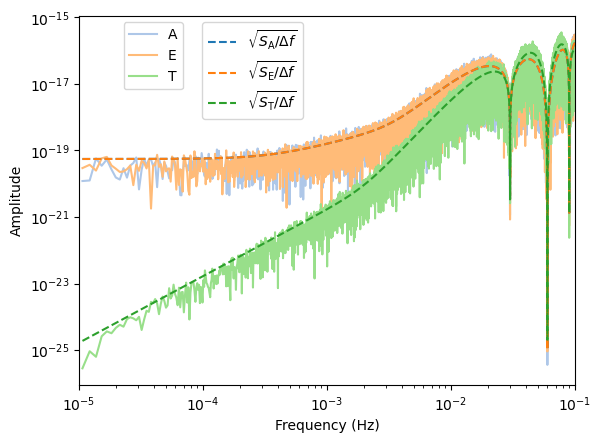

In [4]:
df = tdi_data.data_info.delta_frequency
freqs = tdi_data.data_info.frequency_samples_array
psd = tdi_data.fd_noise_power_density_numpy
noise = tdi_data.fd_data_numpy

tab20_colors = plt.cm.tab20.colors
fig, ax = plt.subplots()
lineA, = ax.loglog(freqs, np.abs(noise['A']), color=tab20_colors[1], label='A')
lineE, = ax.loglog(freqs, np.abs(noise['E']), color=tab20_colors[3], label='E')
lineT, = ax.loglog(freqs, np.abs(noise['T']), color=tab20_colors[5], label='T')

line_psd_A, = ax.loglog(freqs, np.sqrt(psd['A']/df), color=tab20_colors[0], linestyle='dashed', label=r'$\sqrt{S_{\mathrm{A}}/\Delta f}$')
line_psd_E, = ax.loglog(freqs, np.sqrt(psd['E']/df), color=tab20_colors[2], linestyle='dashed', label=r'$\sqrt{S_{\mathrm{E}}/\Delta f}$')
line_psd_T, = ax.loglog(freqs, np.sqrt(psd['T']/df), color=tab20_colors[4], linestyle='dashed', label=r'$\sqrt{S_{\mathrm{T}}/\Delta f}$')

ax.set_xlim(f_min, f_max)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Amplitude')

legend1 = ax.legend(handles=[lineA, lineE, lineT], loc='upper center', bbox_to_anchor=(0.15, 1.0))
legend2 = ax.legend(handles=[line_psd_A, line_psd_E, line_psd_T], loc='upper center', bbox_to_anchor=(0.35, 1.0))
ax.add_artist(legend1)


## Orbit

In [5]:
orbit_model = available_orbit_models['LISA_analytic']

In [6]:
tsamples_np = np.arange(0, lal.YRJUL_SI, 3600)
tsamples = ti.field(ti.f64, shape=tsamples_np.shape)
tsamples.from_numpy(tsamples_np)
orb_vecs = ConstellationVectorStruct.field(shape=tsamples_np.shape)

@ti.kernel
def orbit_test():
    for i in tsamples:
        orb_vecs[i] = orbit_model.get_constellation_vectors(tsamples[i])
orbit_test()

orb_vecs_np = orb_vecs.to_numpy()


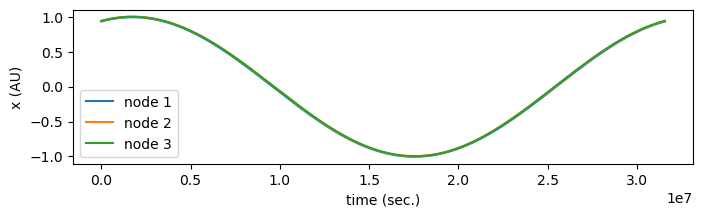

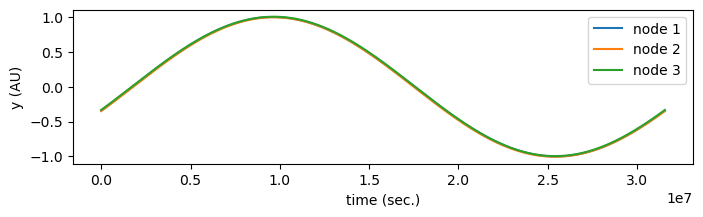

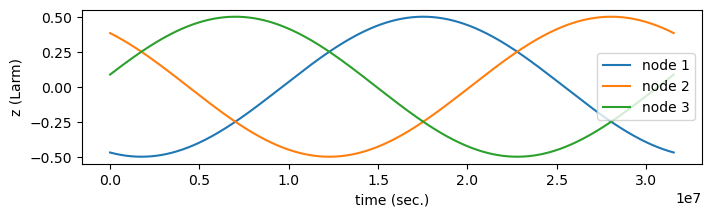

In [7]:
AU_SEC = lal.AU_SI / lal.C_SI

plt.figure(figsize=[8, 2])
plt.plot(tsamples_np, orb_vecs_np["x1"][:, 0] / AU_SEC, label="node 1")
plt.plot(tsamples_np, orb_vecs_np["x2"][:, 0] / AU_SEC, label="node 2")
plt.plot(tsamples_np, orb_vecs_np["x3"][:, 0] / AU_SEC, label="node 3")
plt.ylabel("x (AU)")
plt.xlabel("time (sec.)")
plt.legend()

plt.figure(figsize=[8, 2])
plt.plot(tsamples_np, orb_vecs_np["x1"][:, 1] / AU_SEC, label="node 1")
plt.plot(tsamples_np, orb_vecs_np["x2"][:, 1] / AU_SEC, label="node 2")
plt.plot(tsamples_np, orb_vecs_np["x3"][:, 1] / AU_SEC, label="node 3")
plt.ylabel("y (AU)")
plt.xlabel("time (sec.)")
plt.legend()

plt.figure(figsize=[8, 2])
plt.plot(tsamples_np, orb_vecs_np["x1"][:, 2] / orbit_model.arm_length_sec, label="node 1")
plt.plot(tsamples_np, orb_vecs_np["x2"][:, 2] / orbit_model.arm_length_sec, label="node 2")
plt.plot(tsamples_np, orb_vecs_np["x3"][:, 2] / orbit_model.arm_length_sec, label="node 3")
plt.ylabel("z (Larm)")
plt.xlabel("time (sec.)")
plt.legend()


## Waveform

In [8]:
wf = IMRPhenomXAS(tdi_data.frequency_samples, f_ref)
wf.update_waveform(params)
wf_np = wf.waveform_container_numpy

/home/nrui/disk_ext/workspace/tiwave/tiwave/waveforms/base_waveform.py:69: UserWarning: check_parameters is disable, make sure all parameters passed in are valid.
  warnings.warn(


Text(0.5, 0, 'Frequency (Hz)')

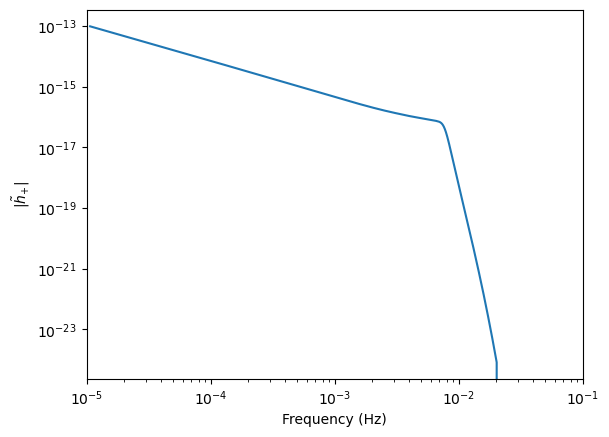

In [9]:
plt.figure()
plt.loglog(freqs, np.abs(wf_np['plus']), label='plus')
plt.xlim(f_min, f_max)
plt.ylabel(r'$|\tilde{h}_{+}|$')
plt.xlabel('Frequency (Hz)')


## Response

In [10]:
response_model = FDResponseModelMarset2018()
tdi_combination = FDMichelsonConstantEqualArm(generation="2.0", orthogonal=True)

lisa = InterferometerAntenna(
    name="lisa",
    tdi_data=tdi_data,
    orbit_model=orbit_model,
    response_model=response_model,
    tdi_combination=tdi_combination,
)
lisa.update_detector_response(
    wf.waveform_container,
    params["ecliptic_longitude"],
    params["ecliptic_latitude"],
    params["polarization"],
    params["coalescence_time"],
)


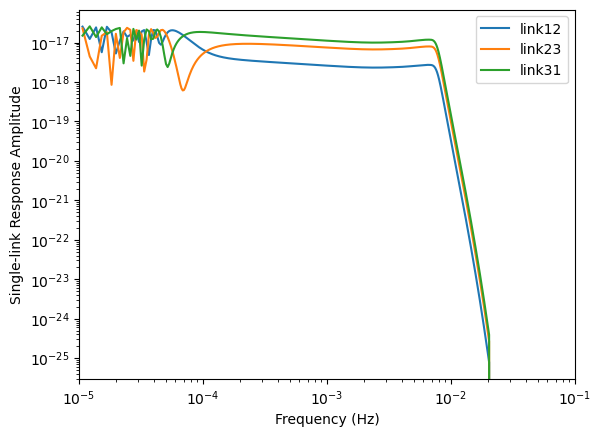

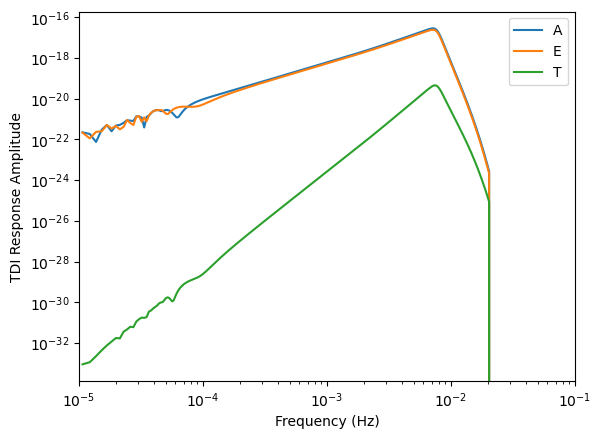

In [11]:
tdi_resp_np = lisa.tdi_response_numpy
link_resp_np = lisa.single_link_response_numpy

plt.figure()
plt.loglog(freqs, np.abs(link_resp_np['link12']), label='link12')
plt.loglog(freqs, np.abs(link_resp_np['link23']), label='link23')
plt.loglog(freqs, np.abs(link_resp_np['link31']), label='link31')
plt.xlim(f_min, f_max)
plt.ylabel('Single-link Response Amplitude')
plt.xlabel('Frequency (Hz)')
plt.legend()

plt.figure()
plt.loglog(freqs, np.abs(tdi_resp_np['A']), label='A')
plt.loglog(freqs, np.abs(tdi_resp_np['E']), label='E')
plt.loglog(freqs, np.abs(tdi_resp_np['T']), label='T')
plt.xlim(f_min, f_max)
plt.ylabel('TDI Response Amplitude')
plt.xlabel('Frequency (Hz)')
plt.legend()

/home/nrui/disk_ext/workspace/tiwave/tiwave/waveforms/IMRPhenomXHM.py:7038: UserWarning: Mode 32 has relatively large numerical errors with lalsim, especially for high spin and extreme mass ratio. See examples/checking_waveforms.ipynb for more details. Please make sure these errors are acceptable in your cases before using.
  warnings.warn(
/home/nrui/disk_ext/workspace/tiwave/tiwave/waveforms/IMRPhenomXHM.py:7045: UserWarning: `tf` is required for mode 32, since the derivative of phase for merge-ringdown of mode 32 is obtained through numerical difference, if may not reliable for some cases.
  warnings.warn(


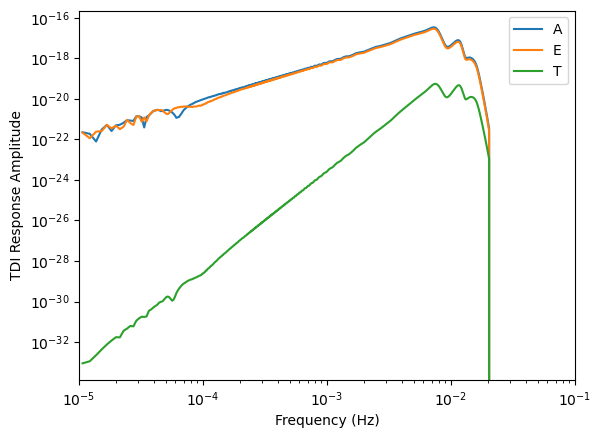

In [12]:
wf_hm = IMRPhenomXHM(tdi_data.frequency_samples, f_ref)
wf_hm.update_waveform(params)
lisa.update_detector_response(
    wf_hm.waveform_container,
    params["ecliptic_longitude"],
    params["ecliptic_latitude"],
    params["polarization"],
    params["coalescence_time"],
)
tdi_resp_np = lisa.tdi_response_numpy
plt.figure()
plt.loglog(freqs, np.abs(tdi_resp_np['A']), label='A')
plt.loglog(freqs, np.abs(tdi_resp_np['E']), label='E')
plt.loglog(freqs, np.abs(tdi_resp_np['T']), label='T')
plt.xlim(f_min, f_max)
plt.ylabel('TDI Response Amplitude')
plt.xlabel('Frequency (Hz)')
plt.legend()

In [13]:
lisa.inject_signal(
    wf.waveform_container,
    params["ecliptic_longitude"],
    params["ecliptic_latitude"],
    params["polarization"],
    params["coalescence_time"],
)

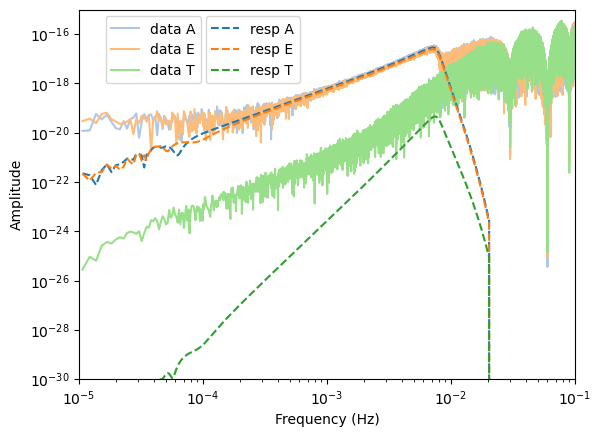

In [14]:
obs_data_np = lisa.tdi_data.fd_data_numpy
tdi_resp_np = lisa.tdi_response_numpy

tab20_colors = plt.cm.tab20.colors
fig, ax = plt.subplots()

line_data_A, = ax.loglog(freqs, np.abs(obs_data_np['A']), color=tab20_colors[1], label='data A')
line_data_E, = ax.loglog(freqs, np.abs(obs_data_np['E']), color=tab20_colors[3], label='data E')
line_data_T, = ax.loglog(freqs, np.abs(obs_data_np['T']), color=tab20_colors[5], label='data T')

line_resp_A, = ax.loglog(freqs, np.abs(tdi_resp_np['A']), color=tab20_colors[0], linestyle='dashed', label='resp A')
line_resp_E, = ax.loglog(freqs, np.abs(tdi_resp_np['E']), color=tab20_colors[2], linestyle='dashed', label='resp E')
line_resp_T, = ax.loglog(freqs, np.abs(tdi_resp_np['T']), color=tab20_colors[4], linestyle='dashed', label='resp T')

ax.set_xlim(f_min, f_max)
ax.set_ylim(1e-30, 1e-15)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Amplitude')

legend1 = ax.legend(
    handles=[line_data_A, line_data_E, line_data_T],
    loc='upper center',
    bbox_to_anchor=(0.15, 1.0),
)

legend2 = ax.legend(
    handles=[line_resp_A, line_resp_E, line_resp_T],
    loc='upper center',
    bbox_to_anchor=(0.35, 1.0),
)

ax.add_artist(legend1)